<a href="https://colab.research.google.com/github/y33ticus-maximus/egt309-project/blob/main/309proj_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Upload Data

upload data

First, let's upload your `.db` file. Click the 'Choose Files' button to select your database file from your local machine.

In [ ]:
from google.colab import files

uploaded = files.upload()

for filename in uploaded.keys():
    print(f'User uploaded file "{filename}"')
    db_filename = filename # Assuming only one .db file is uploaded

Saving gas_monitoring.db to gas_monitoring.db
User uploaded file "gas_monitoring.db"


Now that the file is uploaded, let's connect to it using `sqlite3` and list the tables to get an idea of its structure.

In [ ]:
import sqlite3

if 'db_filename' in locals() and db_filename.endswith('.db'):
    try:
        conn = sqlite3.connect(db_filename)
        cursor = conn.cursor()

        # Get a list of all tables in the database
        cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
        tables = cursor.fetchall()

        print(f"Tables in '{db_filename}':")
        for table in tables:
            print(table[0])

    except Exception as e:
        print(f"Error connecting to or reading from database: {e}")
    finally:
        if 'conn' in locals() and conn:
            conn.close()
else:
    print("No .db file was uploaded or identified.")

Tables in 'gas_monitoring.db':
gas_monitoring


Let's query the `gas_monitoring` table and display the first few rows to understand its structure and content. We'll use `pandas` to read the SQL query result into a DataFrame for easy viewing.

In [ ]:
import pandas as pd
import sqlite3

if 'db_filename' in locals() and db_filename.endswith('.db'):
    try:
        conn = sqlite3.connect(db_filename)
        query = "SELECT * FROM gas_monitoring;"
        df = pd.read_sql_query(query, conn)

        print(f"Successfully queried table 'gas_monitoring'.")
        print("First 5 rows:")
        display(df.head())

    except Exception as e:
        print(f"Error querying table: {e}")
    finally:
        if 'conn' in locals() and conn:
            conn.close()
else:
    print("No .db file was uploaded or identified to query.")

Successfully queried table 'gas_monitoring'.
First 5 rows:


,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
0,morning,19.63,53.83,125.486389,571.089440,478.554958,735.850412,654.625253,565.051969,2.0,7241,off,very_dim,Low Activity
1,morning,292.81,53.69,126.343018,575.789501,491.955151,740.282738,655.734327,557.078486,1.0,7241,ventilation_only,bright,Low Activity
2,morning,19.62,54.25,126.560695,585.543111,505.560808,737.112906,649.962421,558.065196,1.0,7241,eco_mode,None,Low Activity
3,morning,20.10,50.48,113.504877,597.449961,515.142272,744.020651,676.150075,600.222210,NaN,7241,eco_mode,very_bright,High Activity
4,morning,19.89,48.42,92.766225,613.654875,535.664558,770.265441,720.274019,625.731124,1.0,7241,heating_active,moderate,LowActivity


In [ ]:
df['Activity Level'].value_counts()

,count
Activity Level,
Low Activity,5244
Moderate Activity,2812
High Activity,1095
ModerateActivity,326
Low_Activity,285
LowActivity,238


# View Data (EDA)

In [ ]:
df.shape

(10000, 14)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time of Day                10000 non-null  object 
 1   Temperature                10000 non-null  float64
 2   Humidity                   8072 non-null   float64
 3   CO2_InfraredSensor         10000 non-null  float64
 4   CO2_ElectroChemicalSensor  10000 non-null  float64
 5   MetalOxideSensor_Unit1     10000 non-null  float64
 6   MetalOxideSensor_Unit2     8590 non-null   float64
 7   MetalOxideSensor_Unit3     10000 non-null  float64
 8   MetalOxideSensor_Unit4     10000 non-null  float64
 9   CO_GasSensor               9166 non-null   float64
 10  Session ID                 10000 non-null  int64  
 11  HVAC Operation Mode        10000 non-null  object 
 12  Ambient Light Level        8946 non-null   object 
 13  Activity Level             10000 non-null  obje

***Null Values***

In [ ]:
df.isna().sum()

,0
Time of Day,0
Temperature,0
Humidity,1928
CO2_InfraredSensor,0
CO2_ElectroChemicalSensor,0
MetalOxideSensor_Unit1,0
MetalOxideSensor_Unit2,1410
MetalOxideSensor_Unit3,0
MetalOxideSensor_Unit4,0
CO_GasSensor,834


In [ ]:
humid_missing_count = df['Humidity'].isna().value_counts()
print(f"Number of missing values in 'Humidity': {humid_missing_count}")

MS_Unit2 = df['MetalOxideSensor_Unit2'].isna().value_counts()
print(f"Number of missing values in 'MetalOxideSensor_Unit2': {MS_Unit2}")

CO_GS = df['CO_GasSensor'].isna().value_counts()
print(f"Number of missing values in 'CO_GasSensor': {CO_GS}")

Ambient_Light = df['Ambient Light Level'].isna().value_counts()
print(f"Number of missing values in 'AmbientTemperature': {Ambient_Light}")

Number of missing values in 'Humidity': Humidity
False    8072
True     1928
Name: count, dtype: int64
Number of missing values in 'MetalOxideSensor_Unit2': MetalOxideSensor_Unit2
False    8590
True     1410
Name: count, dtype: int64
Number of missing values in 'CO_GasSensor': CO_GasSensor
False    9166
True      834
Name: count, dtype: int64
Number of missing values in 'AmbientTemperature': Ambient Light Level
False    8946
True     1054
Name: count, dtype: int64


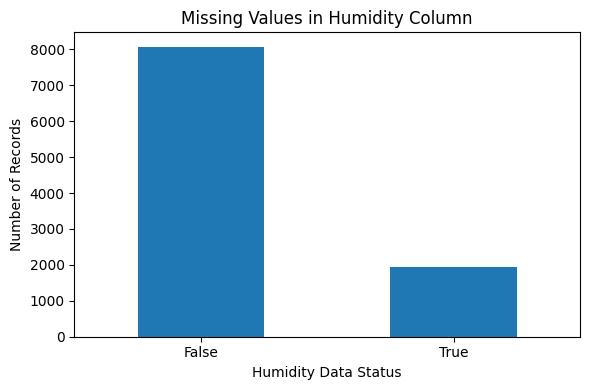

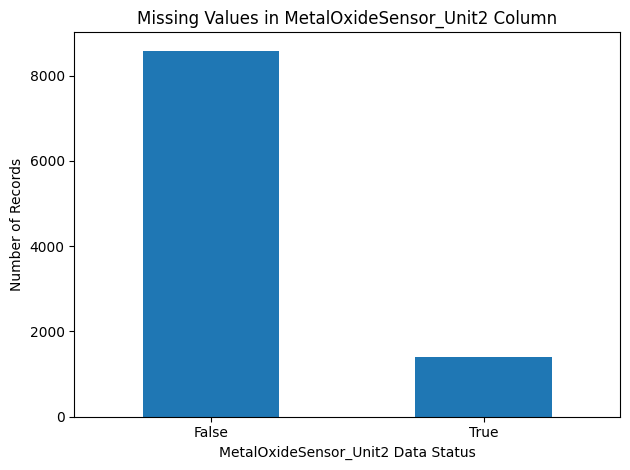

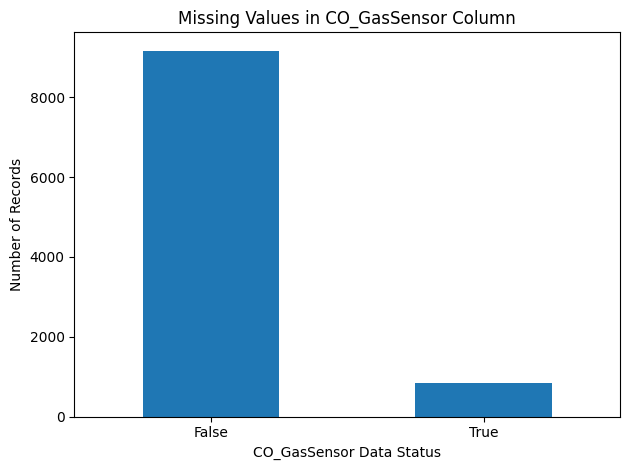

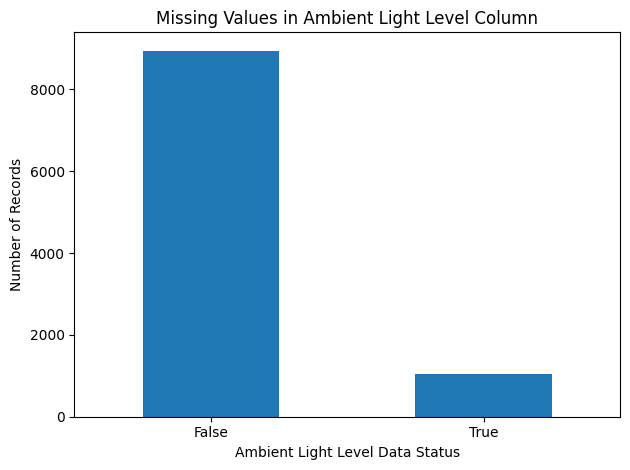

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
humid_missing_count.plot(kind="bar")

plt.title("Missing Values in Humidity Column")
plt.xlabel("Humidity Data Status")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

MS_Unit2.plot(kind="bar")
plt.title("Missing Values in MetalOxideSensor_Unit2 Column")
plt.xlabel("MetalOxideSensor_Unit2 Data Status")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

CO_GS.plot(kind="bar")
plt.title("Missing Values in CO_GasSensor Column")
plt.xlabel("CO_GasSensor Data Status")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Ambient_Light.plot(kind="bar")
plt.title("Missing Values in Ambient Light Level Column")
plt.xlabel("Ambient Light Level Data Status")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Since the total number of null values exceed 5%, We shall perfrom Data Imputation to replace missing values

***Outliers***

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Temperature,10000.0,42.243124,73.974956,6.903485,18.937500,20.510000,23.172500,307.070000
Humidity,8072.0,51.643609,21.333894,-49.870000,47.660000,51.390000,53.840000,198.900000
CO2_InfraredSensor,10000.0,109.864352,33.793851,-17.472184,96.660377,112.807103,124.540226,237.873938
CO2_ElectroChemicalSensor,10000.0,578.634082,22.573537,408.599386,559.353100,579.361082,595.569759,637.895790
MetalOxideSensor_Unit1,10000.0,470.932316,51.459025,286.825662,440.035413,469.146955,494.770045,632.891693
MetalOxideSensor_Unit2,8590.0,728.354408,29.140123,611.168916,709.660122,726.748925,744.879789,807.732943
MetalOxideSensor_Unit3,10000.0,680.488646,55.953530,456.673900,658.519775,679.908353,703.522845,906.213097
MetalOxideSensor_Unit4,10000.0,612.247715,43.174354,412.791904,585.511731,609.526245,636.012105,736.112361
CO_GasSensor,9166.0,1.288239,0.779754,0.000000,1.000000,1.000000,2.000000,4.000000
Session ID,10000.0,5427.921400,2590.836924,1374.000000,3074.000000,5214.000000,7395.000000,9658.000000


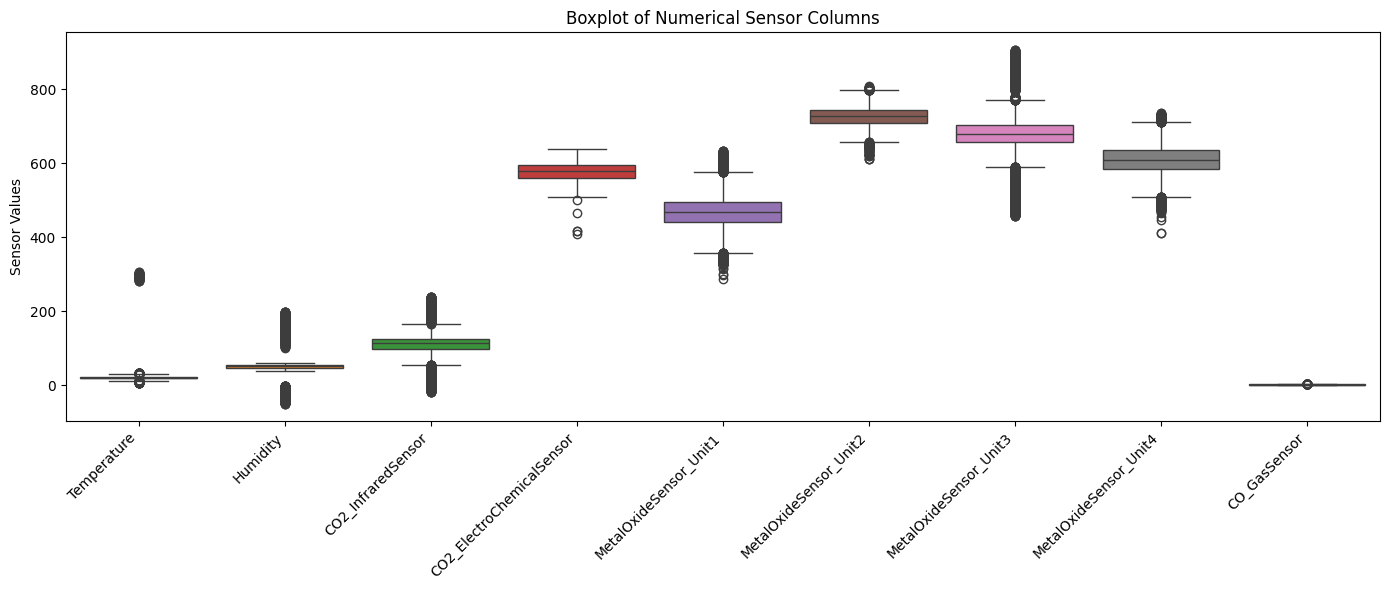

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


# losting numerical columns to check for outliers
cols_to_check = [
    "Temperature",
    "Humidity",
    "CO2_InfraredSensor",
    "CO2_ElectroChemicalSensor",
    "MetalOxideSensor_Unit1",
    "MetalOxideSensor_Unit2",
    "MetalOxideSensor_Unit3",
    "MetalOxideSensor_Unit4",
    "CO_GasSensor"
]

plt.figure(figsize=(14, 6))
sns.boxplot(data=df[cols_to_check]) # Changed df to new_df

plt.title("Boxplot of Numerical Sensor Columns")
plt.ylabel("Sensor Values")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load your clean data
target_column = 'Activity Level'

# 2. Get Raw Counts
print("--- Raw Class Counts ---")
print(df[target_column].value_counts())

# 3. Get Percentages
print("\n--- Class Percentages ---")
# normalize=True gives fractions; multiplying by 100 turns them into percentages
print((df[target_column].value_counts(normalize=True) * 100).round(2).astype(str) + '%')

# 4. Create a Visual Countplot
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=df, x=target_column, ax=ax, palette='viridis', order=df[target_column].value_counts().index)

ax.set_title('Target Variable Distribution (Activity Level)')
ax.set_xlabel('Activity Level')
ax.set_ylabel('Number of Samples')

# Add exact value labels on top of each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.tight_layout()
plt.savefig('activity_level_imbalance.png')
plt.close()

--- Raw Class Counts ---
Activity Level
Low Activity         5244
Moderate Activity    2812
High Activity        1095
ModerateActivity      326
Low_Activity          285
LowActivity           238
Name: count, dtype: int64

--- Class Percentages ---
Activity Level
Low Activity         52.44%
Moderate Activity    28.12%
High Activity        10.95%
ModerateActivity      3.26%
Low_Activity          2.85%
LowActivity           2.38%
Name: proportion, dtype: object


/tmp/ipykernel_3275/3499476724.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=target_column, ax=ax, palette='viridis', order=df[target_column].value_counts().index)


***Duplicate Values***

In [ ]:
df.duplicated().sum()

np.int64(171)

***Column by Column Analysis***

In [ ]:
df['Time of Day'].value_counts()

,count
Time of Day,
afternoon,2635
evening,2476
morning,2460
night,2429


In [ ]:
df['Temperature'].value_counts()

,count
Temperature,
19.46,31
19.48,30
19.00,30
19.51,26
19.45,26
...,...
25.54,1
295.97,1
297.96,1


In [ ]:
df['Humidity'].value_counts()

,count
Humidity,
52.23,18
51.77,16
52.19,15
50.40,15
52.36,15
...,...
58.55,1
191.04,1
55.96,1


In [ ]:
df['CO2_InfraredSensor'].value_counts()

,count
CO2_InfraredSensor,
129.765286,5
97.651034,5
79.689878,4
134.468644,4
102.762985,4
...,...
72.802006,1
69.866936,1
67.894856,1


In [ ]:
df['CO2_ElectroChemicalSensor'].value_counts()

,count
CO2_ElectroChemicalSensor,
577.511795,5
586.289890,5
612.104217,4
549.766466,4
580.675679,4
...,...
616.349705,1
613.654875,1
597.449961,1


In [ ]:
df['MetalOxideSensor_Unit1'].value_counts()

,count
MetalOxideSensor_Unit1,
504.720846,5
441.094969,5
524.411697,4
402.473680,4
436.858763,4
...,...
557.929178,1
535.664558,1
515.142272,1


In [ ]:
df['MetalOxideSensor_Unit2'].value_counts()

,count
MetalOxideSensor_Unit2,
729.083546,4
719.276696,4
758.576868,4
789.853575,3
702.671036,3
...,...
785.334173,1
783.250864,1
784.607235,1


In [ ]:
df['MetalOxideSensor_Unit3'].value_counts()

,count
MetalOxideSensor_Unit3,
674.394586,5
547.609990,4
672.209675,4
707.456772,4
637.685409,3
...,...
687.917991,1
694.772800,1
748.814963,1


In [ ]:
df['MetalOxideSensor_Unit4'].value_counts()

,count
MetalOxideSensor_Unit4,
643.209338,5
612.487827,5
670.023916,4
619.458403,4
589.821252,4
...,...
664.886531,1
625.731124,1
600.222210,1


In [ ]:
df['CO_GasSensor'].value_counts()

,count
CO_GasSensor,
1.0,4722
2.0,2748
0.0,1191
3.0,430
4.0,75


In [ ]:
df['Session ID'].value_counts()

,count
Session ID,
6528,388
4703,387
3418,368
1374,362
5820,357
7058,350
3592,345
2105,341
2847,335


In [ ]:
df['HVAC Operation Mode'].value_counts()

,count
HVAC Operation Mode,
cooling_active,1502
maintenance_mode,1500
heating_active,1468
off,1456
eco_mode,1452
ventilation_only,1394
COOLING_ACTIVE,112
ECO_MODE,112
MAINTENANCE_MODE,106


In [ ]:
df['Ambient Light Level'].value_counts()

,count
Ambient Light Level,
very_bright,3387
bright,2697
moderate,1463
dim,864
very_dim,535


In [ ]:
df['Activity Level'].value_counts()

,count
Activity Level,
Low Activity,5244
Moderate Activity,2812
High Activity,1095
ModerateActivity,326
Low_Activity,285
LowActivity,238
